# QG Framework — Evaluation Notebook

End-to-end evaluation of questions from the 6.042J dataset.

**Sections**
1. Setup & dataset loading
2. Dataset inspection
3. Single-question evaluation (sanity check)
4. Batch evaluation *(~80 min first run; results cached after)*
5. Save & reload results
6. Score analysis by dimension
7. Score analysis by source type (assignment vs exam) + radar comparison
8. Score visualisation (bar chart · box plot · per-dimension radar)
9. Interpretation guide
10. Flagged questions
11. Dive into a specific question

## 1. Setup

In [1]:
import sys
import json
import statistics
from pathlib import Path
from collections import Counter, defaultdict

# Repo root on path
ROOT = Path("..")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from data.pipeline.loader import load_dataset
from src.evaluator import Evaluator
from src.models import EvaluationResult

# Pandas display — show all rows/columns without truncation
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.3f}".format)

print("Imports OK")

2026-03-22 13:34:15.691601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Using default tokenizer.
Using default tokenizer.


Imports OK


## 2. Dataset inspection

In [2]:
# Load all records
pairs = load_dataset(ROOT / "data/dataset.jsonl", data_dir=ROOT / "data")
print(f"Total records: {len(pairs)}")

# Breakdown by source type
from collections import Counter
source_types = Counter(q.metadata.get("source_type") for q, _ in pairs)
print("Source types:", dict(source_types))

Loaded 126 records from ../data/dataset.jsonl


Total records: 126
Source types: {'assignment': 69, 'exam': 57}


In [3]:
# Inspect a sample record
q, ctx = pairs[0]
print("=== Question ===")
print(f"  id          : {q.id}")
print(f"  subject     : {q.subject}")
print(f"  grade_level : {q.grade_level}")
print(f"  source_type : {q.metadata.get('source_type')}")
print(f"  text        : {q.text[:200]}")
print()
print("=== Context ===")
print(f"  objectives  : {ctx.learning_objectives[:2]}")
print(f"  content     : {str(ctx.course_content)[:200]}")
print(f"  bm25_score  : {ctx.metadata.get('bm25_score')}")
print(f"  topic       : {ctx.metadata.get('topic')}")

=== Question ===
  id          : 6.042J-A0001
  subject     : Mathematics for Computer Science
  grade_level : undergraduate
  source_type : assignment
  text        : Problem 1. [16 points] Warmup Exercises
For the following parts, a correct numerical answer will only earn credit if accompanied by
it’s derivation. Show your work.
(a) [4 pts] Use the Pulverizer to f

=== Context ===
  objectives  : ['Explain and apply basic methods of discrete mathematics in Computer Science', 'Reason mathematically about basic data types and structures (numbers, sets, graphs, trees) used in computer algorithms and systems']
  content     : X 1 Y 1 D ns 11=ps nD1 p2primes The sum on the left is obtained by multiplying out all the infinite series and ap- plying the Fundamental Theorem of Arithmetic. For example, the term 1=300s in the sum
  bm25_score  : 95.4418
  topic       : X 1 Y 1 D ns 11=ps nD1 p2primes The sum on the left is obtained by multiplying o


## 3. Single-question evaluation (sanity check)

Run one question through the full evaluator before committing to a batch run.

In [4]:
evaluator = Evaluator()

q, ctx = pairs[0]
result = evaluator.evaluate(q, ctx)

print(f"Question: {q.text[:100]}")
print()

flat = result.flat_scores()
for aspect, dims in flat.items():
    print(f"[{aspect}]")
    for dim, metrics in dims.items():
        scores_str = "  ".join(f"{m}: {v:.3f}" for m, v in metrics.items())
        print(f"  {dim}: {scores_str}")
    print()

Loading BLEURT checkpoint 'BLEURT-20' …


Computing checksums: 100%|##########| 1/1 [00:06<00:00,  6.83s/it]

INFO:tensorflow:Reading checkpoint /Users/omaramraninejjar/.cache/huggingface/metrics/bleurt/BLEURT-20/downloads/extracted/70c62aa7a372eb34bb38ca18bd541476a9e4b838703dbd605431f0c8cace247e/BLEURT-20.


Reading checkpoint /Users/omaramraninejjar/.cache/huggingface/metrics/bleurt/BLEURT-20/downloads/extracted/70c62aa7a372eb34bb38ca18bd541476a9e4b838703dbd605431f0c8cace247e/BLEURT-20.


INFO:tensorflow:Config file found, reading.


...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Loading NLI cross-encoder 'cross-encoder/nli-deberta-v3-small' …
Use pytorch device: mps


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Loading GPT-2 for LM perplexity (first use — ~500 MB download)…
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Question: Problem 1. [16 points] Warmup Exercises
For the following parts, a correct numerical answer will onl

[pedagogical]
  curriculum_alignment: bleu: 0.002  rouge_l: 0.067  meteor: 0.148  chrf: 0.219  tfidf: 0.100  bm25: 1.000  bertscore: 0.674  bleurt: 0.372  bartscore: 0.102  comet: 0.474  sbert: 0.320  nli_entailment: 0.003
  cognitive_demand: bloom_level: 0.500  dok_level: 0.500  hots_keywords: 0.000
  concept_coverage: bleu: 0.001  rouge_l: 0.088  meteor: 0.078  chrf: 0.075  tfidf: 0.253  bm25: 0.000  bertscore: 0.698  bleurt: 0.147  bartscore: 0.140  comet: 0.565  sbert: 0.276  nli_entailment: 0.011
  response_burden: openendedness: 0.700  sqp_score: 1.000  multipart_question: 0.500  stem_complexity: 0.140

[psychometric]
  difficulty: 
  discrimination: 
  guessing_careless: 
  distractor_functioning: 
  item_fit: 
  dimensionality: 
  reliability: 

[linguistic_structural]
  readability: word_count: 1.000  sentence_count: 1.000  avg_word_length: 0.592  avg_syllables: 0.62

## 4. Batch evaluation

Each question has its own BM25-retrieved context, so we evaluate each `(question, context)` pair independently.

`tqdm` is optional — remove the import and replace with a plain loop if not installed (`pip install tqdm`).

In [5]:
try:
    from tqdm.notebook import tqdm
except ImportError:
    tqdm = lambda x, **kw: x  # noqa: E731

results = []
errors = []

for q, ctx in tqdm(pairs, desc="Evaluating"):
    try:
        results.append(evaluator.evaluate(q, ctx))
    except Exception as e:
        errors.append((q.id, str(e)))
        results.append(None)

ok = sum(1 for r in results if r is not None)
print(f"Done: {ok}/{len(pairs)} succeeded, {len(errors)} errors")
if errors:
    for qid, msg in errors[:5]:
        print(f"  {qid}: {msg}")

Evaluating:   0%|          | 0/126 [00:00<?, ?it/s]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Done: 126/126 succeeded, 0 errors


## 5. Save & reload results

Run the **save** cell once after the batch evaluation. Future sessions can skip the batch and go straight to **reload**.

In [6]:
# ── SAVE (run once after batch evaluation) ──────────────────────────────────
RESULTS_PATH = ROOT / "data/results/6.042J_results.jsonl"
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

# Build `valid` here if coming straight from batch cell
valid = [(p, r) for p, r in zip(pairs, results) if r is not None]

with RESULTS_PATH.open("w", encoding="utf-8") as f:
    for (q, ctx), result in valid:
        # Save full metric info: score + flagged + rationale
        full_scores = {
            asp: {
                dim: {
                    m: {"score": mr.score, "flagged": mr.flagged,
                        "rationale": mr.rationale}
                    for m, mr in dim_res.scores.items()
                }
                for dim, dim_res in asp_res.scores.items()
            }
            for asp, asp_res in result.scores.items()
        }
        row = {
            "question_id": q.id,
            "source_type": q.metadata.get("source_type"),
            "source_label": q.metadata.get("source_label"),
            "course_id": q.metadata.get("course_id"),
            "bm25_score": ctx.metadata.get("bm25_score"),
            "topic": ctx.metadata.get("topic"),
            "course_content": ctx.course_content,
            "question_text": q.text,
            "scores": full_scores,
        }
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Saved {len(valid)} results → {RESULTS_PATH}")

Saved 126 results → ../data/results/6.042J_results.jsonl


In [7]:
# ── RELOAD (future sessions: run this instead of batch + save) ──────────────
RESULTS_PATH = ROOT / "data/results/6.042J_results.jsonl"
saved_rows = [json.loads(l) for l in RESULTS_PATH.open(encoding="utf-8")]

def _rebuild_valid(rows):
    from src.models import (Question, EvaluationContext, EvaluationResult,
                            AspectResult, DimensionResult, MetricResult)
    out = []
    for row in rows:
        q = Question(
            id=row["question_id"], text=row["question_text"],
            metadata={"source_type": row["source_type"],
                      "source_label": row["source_label"],
                      "course_id": row["course_id"],
                      "bm25_score": row["bm25_score"]},
        )
        ctx = EvaluationContext(
            course_content=row.get("course_content"),
            metadata={"bm25_score": row["bm25_score"],
                      "topic": row.get("topic")},
        )
        asp_scores = {}
        for asp_name, dims in row["scores"].items():
            dim_scores = {}
            for dim_name, metrics in dims.items():
                metric_results = {}
                for m, v in metrics.items():
                    # Handle both old format (float) and new format (dict)
                    if isinstance(v, dict):
                        metric_results[m] = MetricResult(
                            metric_name=m, score=v["score"],
                            flagged=v.get("flagged", False),
                            rationale=v.get("rationale", ""),
                        )
                    else:
                        metric_results[m] = MetricResult(metric_name=m, score=v)
                dim_scores[dim_name] = DimensionResult(
                    dimension=dim_name, scores=metric_results)
            asp_scores[asp_name] = AspectResult(aspect=asp_name, scores=dim_scores)
        out.append(((q, ctx), EvaluationResult(question_id=q.id, scores=asp_scores)))
    return out

valid = _rebuild_valid(saved_rows)
print(f"Reloaded {len(valid)} results from {RESULTS_PATH}")

Reloaded 126 results from ../data/results/6.042J_results.jsonl


### How scores are computed

Every metric returns a value in **[0, 1]** using its own normalisation.
The table below shows the method per category:

| Metric category | Raw value | Normalisation |
|---|---|---|
| Formula readability (Flesch, Gunning Fog, …) | 0–100 scale | `raw / 100`, clamped to [0, 1] |
| Inverted-scale metrics (avg word length, syllables) | length / ratio | `1 − clamp(raw / ceiling)` |
| Ratio / proportion metrics (long-word ratio, passive voice) | already 0–1 | used directly or inverted |
| Model-based similarity (BERTScore, SentenceBERT, BM25) | cosine / F1 | already in [0, 1] or normalised by max |
| Count metrics (word count, sentence count) | integer | `clamp(count / max_expected)` |
| Risk / privacy metrics | event flag | 0.0 (risk present) or 1.0 (clean) |

**Aggregation levels:**

```
Metric score  (0–1)     individual formula/model output
     │  unweighted mean (Scorer.aggregate_dimension)
     ▼
Dimension score (0–1)   e.g. readability = mean of 16 readability metrics
     │  unweighted mean (Scorer.aggregate_aspect)
     ▼
Aspect score  (0–1)     e.g. linguistic_structural = mean of 5 dimension scores
     │  unweighted mean (Scorer.aggregate_evaluation)
     ▼
Overall score (0–1)     mean of 4 aspect scores
```

**Is this approach standard?**

Yes — unweighted mean aggregation is the default in most multi-metric NLP evaluation frameworks:

- **HELM** (Liang et al., 2022, *Holistic Evaluation of Language Models*) aggregates 42 scenarios using a mean of normalised metric scores per scenario, then a mean across scenarios.
- **BIG-Bench** (Srivastava et al., 2022) normalises each task score to [0, 1] and reports the unweighted mean (BIG-Bench score) as the headline number.
- **AERA/APA/NCME Standards for Educational and Psychological Testing** (2014, §4) recommend combining content-validity evidence across judges/criteria using mean scores, with equal weights as the neutral default unless differential importance is theoretically justified.
- The **min-gate** strategy used for safety/risk dimensions (return the minimum score) mirrors the *conjunction* rule in safety-critical systems — one failure is enough to flag the item. It is used in OpenAI's eval harness and in OECD PISA's item-flagging protocol.

All weights are **equal by default**. Custom `weights={}` can be passed to `Scorer` to prioritise certain dimensions (e.g. downweight psychometric until student-response data is available).

## 6. Score analysis by dimension

In [8]:
rows = []
for (q, ctx), result in valid:
    for aspect, dims in result.flat_scores().items():
        for dim, metrics in dims.items():
            for metric, score in metrics.items():
                rows.append({"aspect": aspect, "dimension": dim,
                             "metric": metric, "score": score,
                             "source_type": q.metadata.get("source_type"),
                             "question_id": q.id})

df = pd.DataFrame(rows)

# Mean ± std per dimension
summary = (
    df.groupby(["aspect", "dimension"])["score"]
    .agg(mean="mean", std="std", min="min", max="max", n="count")
    .reset_index()
    .sort_values(["aspect", "dimension"])
)
summary

,aspect,dimension,mean,std,min,max,n
0,fairness_ethics,privacy_risk,0.692,0.364,0.000,1.000,378
1,linguistic_structural,ambiguity,0.702,0.325,0.000,1.000,630
2,linguistic_structural,diversity,0.717,0.198,0.250,1.000,504
3,linguistic_structural,linguistic_complexity,0.500,0.363,0.000,1.000,756
4,linguistic_structural,readability,0.590,0.269,0.000,1.000,2016
5,linguistic_structural,well_formedness,0.676,0.393,0.000,1.000,756
6,pedagogical,cognitive_demand,0.504,0.315,0.000,1.000,378
7,pedagogical,concept_coverage,0.210,0.223,0.000,0.968,1512
8,pedagogical,curriculum_alignment,0.271,0.275,0.000,1.000,1512
9,pedagogical,response_burden,0.421,0.333,0.000,1.000,504


In [9]:
from src.scorer import Scorer

scorer = Scorer()

# Compute dimension-level and aspect-level aggregated scores
dim_rows = []
for (q, ctx), result in valid:
    for asp_name, asp_res in result.scores.items():
        asp_score = scorer.aggregate_aspect(asp_res)
        for dim_name, dim_res in asp_res.scores.items():
            dim_score = scorer.aggregate_dimension(dim_res)
            dim_rows.append({
                "aspect": asp_name,
                "dimension": dim_name,
                "dim_score": dim_score,
                "asp_score": asp_score,
                "source_type": q.metadata.get("source_type"),
                "question_id": q.id,
            })

df_dim = pd.DataFrame(dim_rows)

# Summary table: dimension scores across all questions
dim_summary = (
    df_dim.groupby(["aspect", "dimension"])["dim_score"]
    .agg(mean="mean", std="std", min="min", max="max")
    .reset_index()
    .sort_values(["aspect", "mean"], ascending=[True, False])
)
dim_summary.style.background_gradient(subset=["mean"], cmap="RdYlGn", vmin=0, vmax=1)

,aspect,dimension,mean,std,min,max
4,fairness_ethics,privacy_risk,0.691619,0.265412,0.285057,1.000000
0,fairness_ethics,content_sensitivity,0.000000,0.000000,0.000000,0.000000
1,fairness_ethics,group_bias,0.000000,0.000000,0.000000,0.000000
2,fairness_ethics,harmful_content_risk,0.000000,0.000000,0.000000,0.000000
3,fairness_ethics,measurement_invariance,0.000000,0.000000,0.000000,0.000000
6,linguistic_structural,diversity,0.716687,0.064776,0.579101,0.959887
5,linguistic_structural,ambiguity,0.702496,0.074883,0.490538,0.869126
9,linguistic_structural,well_formedness,0.675870,0.091495,0.446589,0.936565
8,linguistic_structural,readability,0.590151,0.068672,0.377678,0.751925
7,linguistic_structural,linguistic_complexity,0.500320,0.099474,0.338331,0.732247


## 7. Score analysis by source type (assignment vs exam)

In [10]:
pivot = (
    df.groupby(["aspect", "dimension", "source_type"])["score"]
    .mean()
    .unstack("source_type")
    .reset_index()
)
pivot["diff (exam - assign)"] = pivot.get("exam", 0) - pivot.get("assignment", 0)
pivot.sort_values("aspect")

source_type,aspect,dimension,assignment,exam,diff (exam - assign)
0,fairness_ethics,privacy_risk,0.664,0.726,0.062
1,linguistic_structural,ambiguity,0.706,0.699,-0.007
2,linguistic_structural,diversity,0.704,0.732,0.028
3,linguistic_structural,linguistic_complexity,0.499,0.503,0.004
4,linguistic_structural,readability,0.587,0.594,0.007
5,linguistic_structural,well_formedness,0.698,0.649,-0.049
6,pedagogical,cognitive_demand,0.502,0.505,0.003
7,pedagogical,concept_coverage,0.224,0.192,-0.032
8,pedagogical,curriculum_alignment,0.279,0.261,-0.018
9,pedagogical,response_burden,0.392,0.455,0.063


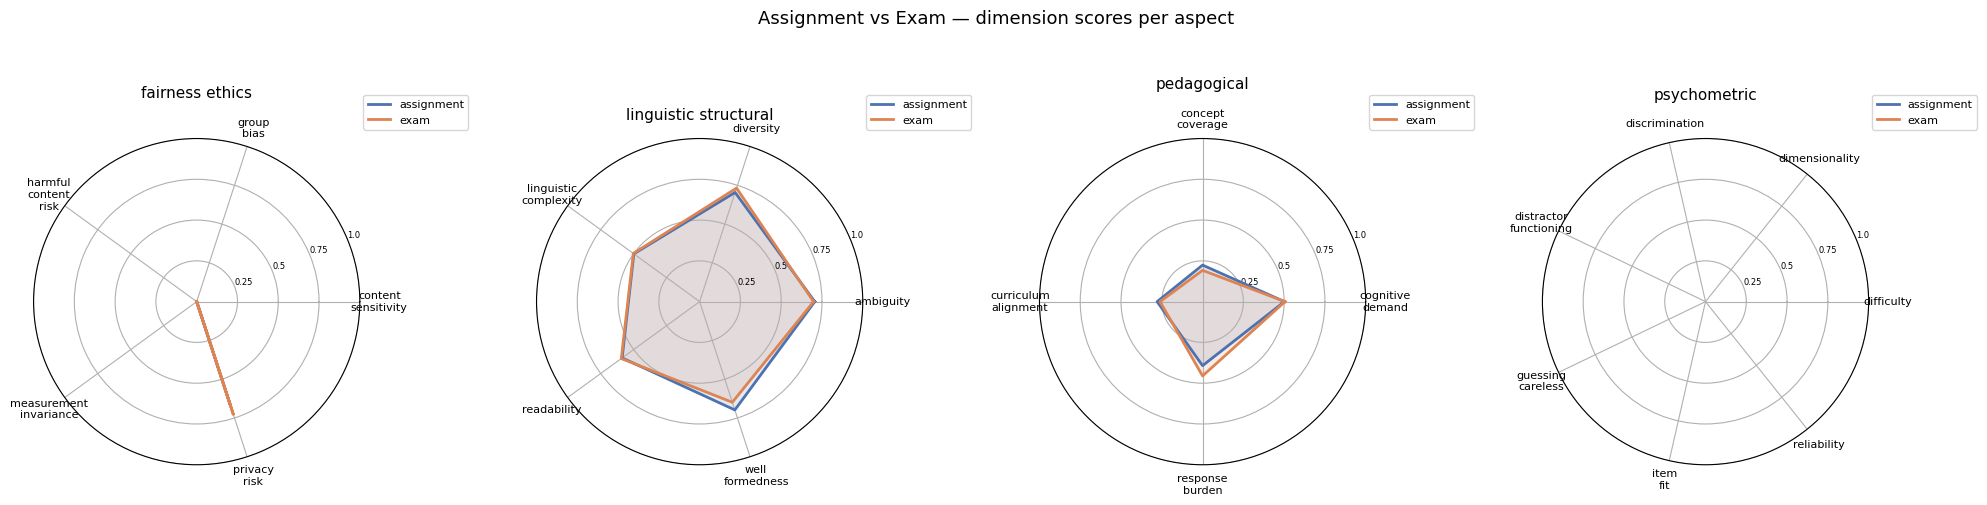

In [11]:
# Radar chart per aspect — comparing assignment vs exam dimension scores

from src.scorer import Scorer
import matplotlib.pyplot as plt
import numpy as np

scorer = Scorer()
aspects = sorted(df_dim["aspect"].unique())
source_types = sorted(df_dim["source_type"].dropna().unique())
colors = {"assignment": "#4C72B0", "exam": "#DD8452"}

fig, axes = plt.subplots(1, len(aspects), figsize=(5 * len(aspects), 5),
                          subplot_kw=dict(polar=True))
if len(aspects) == 1:
    axes = [axes]

for ax, asp in zip(axes, aspects):
    dims_in_asp = sorted(df_dim[df_dim["aspect"] == asp]["dimension"].unique())
    N = len(dims_in_asp)
    if N < 3:
        ax.set_visible(False)
        continue
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles_closed = angles + angles[:1]

    for st in source_types:
        sub = df_dim[(df_dim["aspect"] == asp) & (df_dim["source_type"] == st)]
        vals = [sub[sub["dimension"] == d]["dim_score"].mean()
                for d in dims_in_asp]
        vals_closed = vals + vals[:1]
        c = colors.get(st, "grey")
        ax.plot(angles_closed, vals_closed, color=c, linewidth=2, label=st)
        ax.fill(angles_closed, vals_closed, color=c, alpha=0.15)

    ax.set_xticks(angles)
    ax.set_xticklabels(
        [d.replace("_", "\n") for d in dims_in_asp], size=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], size=6)
    ax.set_title(asp.replace("_", " "), size=11, pad=14)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=8)

fig.suptitle("Assignment vs Exam — dimension scores per aspect", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Score visualisation

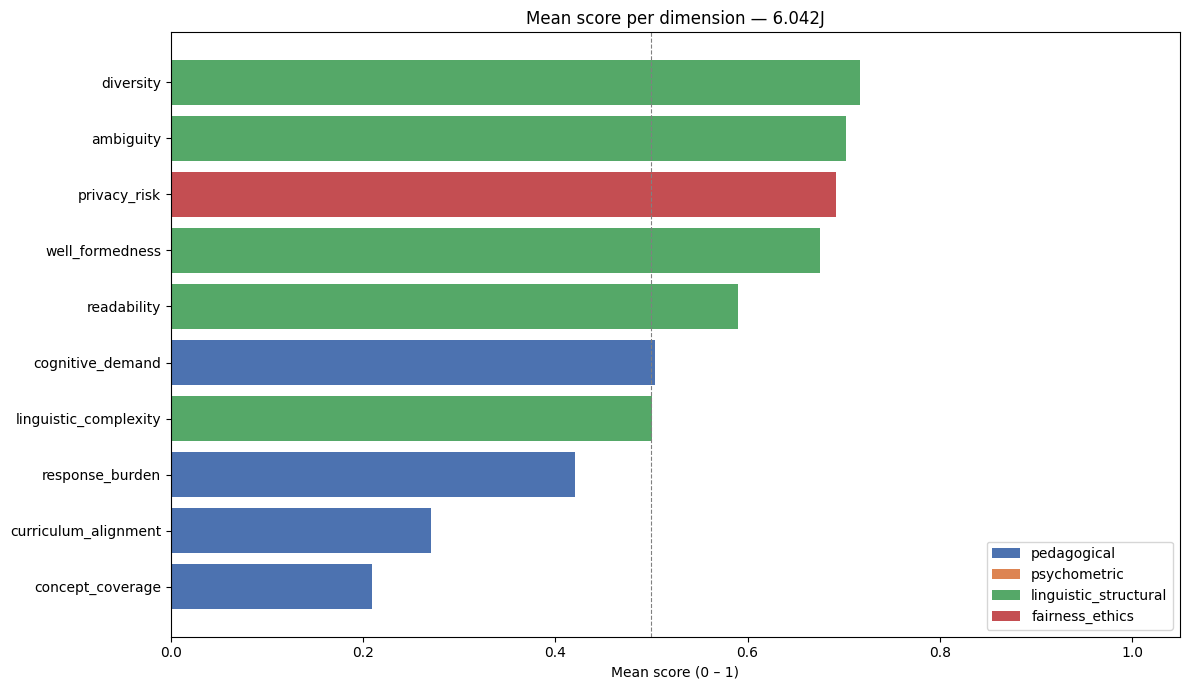

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

dim_mean = df.groupby("dimension")["score"].mean().sort_values()
aspects_for_dim = df.groupby("dimension")["aspect"].first()
aspect_colors = {"pedagogical": "#4C72B0", "psychometric": "#DD8452",
                 "linguistic_structural": "#55A868", "fairness_ethics": "#C44E52"}
colors = [aspect_colors.get(aspects_for_dim[d], "#8172B3") for d in dim_mean.index]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(dim_mean.index, dim_mean.values, color=colors)
ax.axvline(0.5, color="grey", linestyle="--", linewidth=0.8, label="0.5 midpoint")
ax.set_xlabel("Mean score (0 – 1)")
ax.set_title("Mean score per dimension — 6.042J")
ax.set_xlim(0, 1.05)

# Legend for aspects
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=a) for a, c in aspect_colors.items()]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

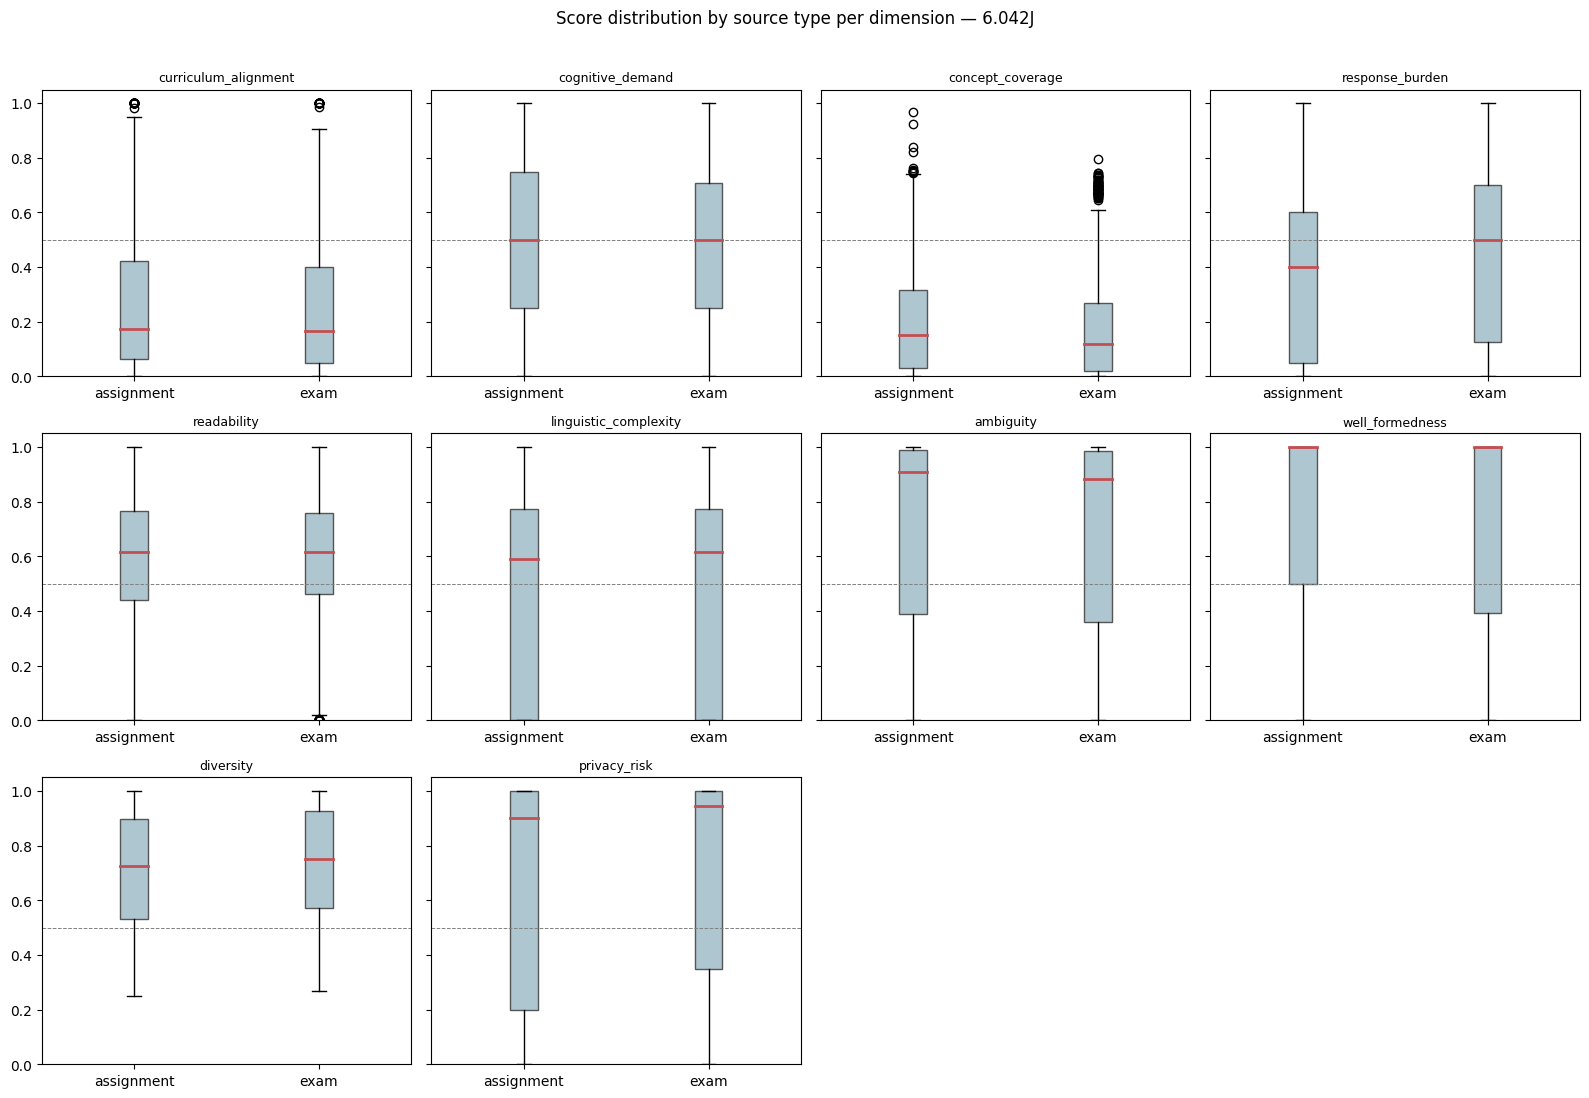

In [13]:
# Box plot — score distribution by source type per dimension
fig, axes = plt.subplots(4, 4, figsize=(16, 14), sharey=True)
axes = axes.flatten()

dims = df["dimension"].unique()
for ax, dim in zip(axes, dims):
    grp = df[df["dimension"] == dim]
    data = [grp[grp["source_type"] == st]["score"].values
            for st in grp["source_type"].unique()]
    labels = list(grp["source_type"].unique())
    ax.boxplot(data, labels=labels, patch_artist=True,
               boxprops=dict(facecolor="#AEC6CF", color="#555"),
               medianprops=dict(color="#C44E52", linewidth=2))
    ax.set_title(dim, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.7)

# Hide unused subplots
for ax in axes[len(dims):]:
    ax.set_visible(False)

fig.suptitle("Score distribution by source type per dimension — 6.042J", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

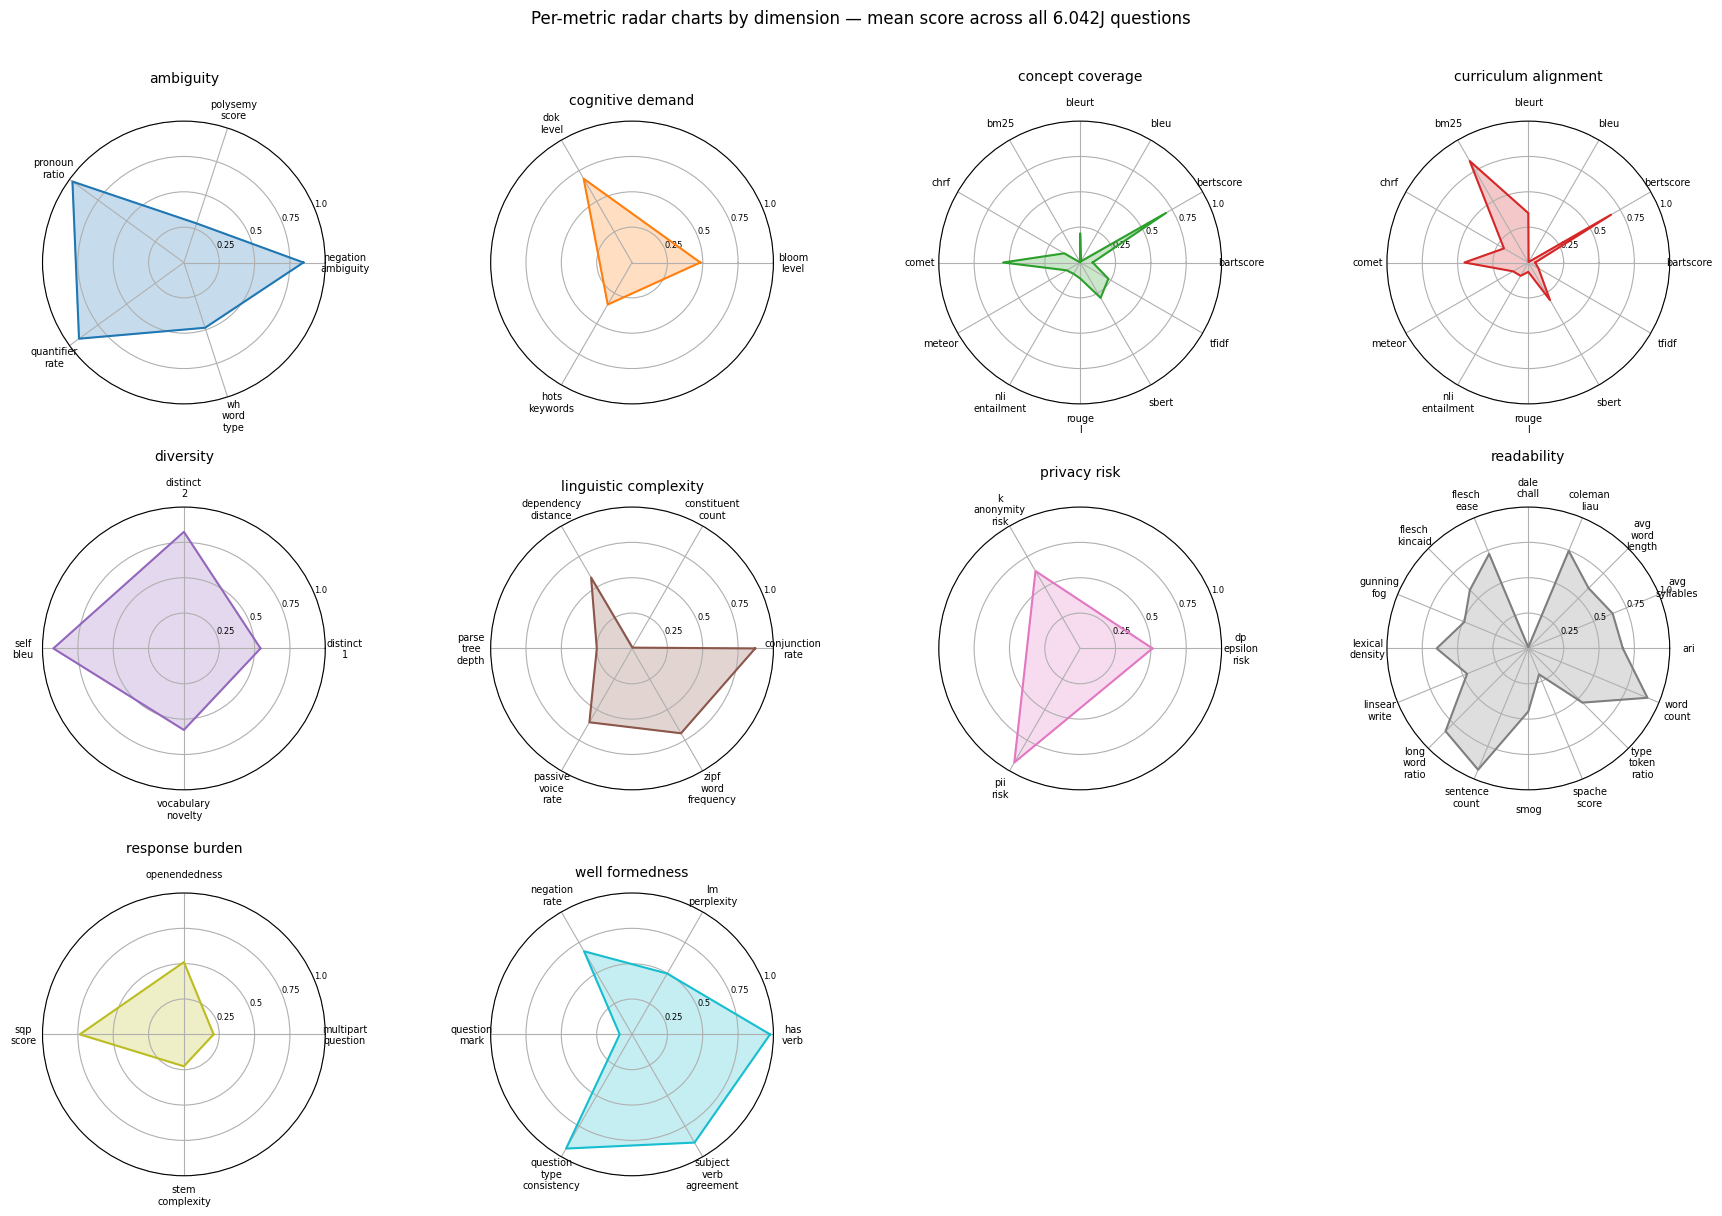

In [14]:
# Radar charts — per-metric breakdown inside each dimension
# One subplot per dimension; spokes = individual metric scores (mean across questions)

import matplotlib.pyplot as plt
import numpy as np

dims_list = df["dimension"].unique().tolist()
ncols = 4
nrows = int(np.ceil(len(dims_list) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4),
                          subplot_kw=dict(polar=True))
axes = axes.flatten()

palette = plt.get_cmap("tab10")

for ax_i, dim in enumerate(sorted(dims_list)):
    ax = axes[ax_i]
    sub = df[df["dimension"] == dim]
    metric_means = sub.groupby("metric")["score"].mean()
    labels = metric_means.index.tolist()
    values = metric_means.values.tolist()
    N = len(labels)
    if N < 3:
        ax.set_visible(False)
        continue
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]       # close the polygon
    values += values[:1]
    color = palette(ax_i % 10)
    ax.plot(angles, values, color=color, linewidth=1.5)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [l.replace("_", "\n") for l in labels],
        size=7
    )
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], size=6)
    ax.set_title(dim.replace("_", " "), size=10, pad=12)

for ax in axes[len(dims_list):]:
    ax.set_visible(False)

fig.suptitle("Per-metric radar charts by dimension — mean score across all 6.042J questions",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 9. Interpretation guide

### Score scale

| Band | Range | Reading |
|---|---|---|
| Strong | 0.80 – 1.00 | Clearly satisfied; no concern |
| Acceptable | 0.60 – 0.80 | Minor weakness; worth monitoring |
| Borderline | 0.40 – 0.60 | Real concern; investigate flagged questions |
| Problematic | 0.00 – 0.40 | Systematic issue in this dimension |

---

### Pedagogical aspect

| Dimension | Score direction | Low score means |
|---|---|---|
| Curriculum alignment | Higher = more aligned | Question tests outside declared objectives |
| Cognitive demand | Higher = more higher-order | Predominantly recall / recognition items |
| Concept coverage | Higher = better coverage | Vocabulary redundant; concepts not distributed |
| Response burden | Higher = appropriate length | Questions too long, complex, or too brief |

---

### Psychometric aspect

*Scores are placeholders — requires real student-response data.*

| Dimension | What it will measure |
|---|---|
| Difficulty | Item difficulty index (p-value) |
| Discrimination | Point-biserial / IRT a-parameter |
| Distractor functioning | MCQ option uptake |
| Item fit | Infit / outfit statistics |

---

### Linguistic & Structural aspect

| Dimension | Score direction | Low score means |
|---|---|---|
| Readability | Higher = more readable | Text too dense for target population |
| Linguistic complexity | Higher = simpler syntax | Syntactically over-engineered |
| Ambiguity | Higher = less ambiguous | Multiple valid interpretations possible |
| Well-formedness | Higher = better formed | Grammatically / structurally malformed |
| Diversity | Higher = more diverse | Questions too similar; low topic coverage |

---

### Fairness & Ethics aspect

| Dimension | Score direction | Low score means |
|---|---|---|
| Group bias | Higher = less biased | Language may disadvantage a demographic group |
| Content sensitivity | Higher = less sensitive | References distressing topics |
| Harmful content risk | Higher = safer | Possible policy violation |
| Privacy risk | Higher = lower risk | PII or re-identification risk present |
| Measurement invariance | n/a | Requires IRT DIF analysis with response data |

---

### Reading 6.042J results in context

- **Psychometric scores near 0.5** are placeholders. Filter them out of summary charts until student-response data is attached.
- **Readability 0.3–0.5** is expected for undergraduate mathematics — complex notation and domain vocabulary are inherent; this is not a flaw.
- **Curriculum alignment** compares question wording to broad learning objectives (e.g. "apply proof techniques"). Questions on narrow sub-topics (modular arithmetic, graph coloring) will naturally score lower even when pedagogically correct.
- **Diversity / Self-BLEU near 1.0** means questions are lexically distinct — good. A low score would indicate near-duplicate items.
- **Flagged metrics** (Section 10) are worth investigating individually; a flag means a metric crossed its threshold, not that the question is invalid.

## 10. Flagged questions

Questions where at least one metric raised a flag.

In [15]:
# Guard: valid must exist (run reload cell first if starting fresh)
if 'valid' not in dir() or not valid:
    raise RuntimeError("Run the reload cell (Section 5) first — valid is not defined.")

# Try native flagged attribute first (new format)
flagged = [
    (q, result)
    for (q, ctx), result in valid
    if any(
        mr.flagged
        for asp in result.scores.values()
        for dim in asp.scores.values()
        for mr in dim.scores.values()
    )
]

# Fallback: if saved file predates flagged support, flag by score < 0.30
FLAG_THRESHOLD = 0.30
if not flagged:
    print(f"(No flagged=True in saved data — using score < {FLAG_THRESHOLD} as fallback)")
    print()
    flagged = [
        (q, result)
        for (q, ctx), result in valid
        if any(
            mr.score < FLAG_THRESHOLD
            for asp in result.scores.values()
            for dim in asp.scores.values()
            for mr in dim.scores.values()
        )
    ]

print(f"{len(flagged)} questions with at least one low-scoring metric (out of {len(valid)})")
print()
for q, result in flagged[:5]:
    print(f"[{q.id}]  {q.metadata.get('source_type')} / {q.metadata.get('source_label')}")
    print(f"  Text: {q.text[:120]}")
    for asp_name, asp in result.scores.items():
        for dim_name, dim in asp.scores.items():
            for m_name, mr in dim.scores.items():
                is_flagged = mr.flagged or mr.score < FLAG_THRESHOLD
                if is_flagged:
                    rat = f" — {mr.rationale}" if mr.rationale else ""
                    print(f"  LOW  {asp_name}/{dim_name}/{m_name}: {mr.score:.3f}{rat}")
    print()

126 questions with at least one low-scoring metric (out of 126)

[6.042J-A0001]  assignment / Mit6 042Jf10 Assn03
  Text: Problem 1. [16 points] Warmup Exercises
For the following parts, a correct numerical answer will only earn credit if acc
  LOW  pedagogical/curriculum_alignment/bleu: 0.002 — BLEU 0.0024 (weak overlap) vs 14 reference(s) from context.learning_objectives.
  LOW  pedagogical/curriculum_alignment/rouge_l: 0.067 — ROUGE-L fmeasure 0.0672 (weak overlap) vs 14 reference(s) from context.learning_objectives.
  LOW  pedagogical/curriculum_alignment/meteor: 0.148 — METEOR 0.1479 (weak alignment) vs 14 reference(s) from context.learning_objectives.
  LOW  pedagogical/curriculum_alignment/chrf: 0.219 — chrF 0.2189 (weak character-level overlap) vs 14 reference(s) from context.learning_objectives.
  LOW  pedagogical/curriculum_alignment/tfidf: 0.100 — TF-IDF cosine 0.0996 (weak keyword-weighted similarity) vs 14 reference(s) from context.learning_objectives.
  LOW  pedagogical/c

## 11. Dive into a specific question

Pick any question by index and inspect all its scores.

In [16]:
# Guard: valid must exist (run reload cell first if starting fresh)
if 'valid' not in dir() or not valid:
    raise RuntimeError("Run the reload cell (Section 5) first — valid is not defined.")

# Change this index to inspect a different question (0 … len(valid)-1)
IDX = 0

(q, ctx), result = valid[IDX]

print("=" * 70)
print(f"ID          : {q.id}")
print(f"Source      : {q.metadata.get('source_type')} / {q.metadata.get('source_label')}")
print(f"Course      : {q.metadata.get('course_id')}")
print(f"BM25 score  : {ctx.metadata.get('bm25_score')}")
print(f"Topic       : {ctx.metadata.get('topic')}")
print("=" * 70)
print("QUESTION TEXT:")
print(q.text)
print()
if ctx.course_content:
    print("RETRIEVED PASSAGE (first 500 chars):")
    print(ctx.course_content[:500])
else:
    print("RETRIEVED PASSAGE: (not saved — re-save results to include passage)")
print()
print("SCORES:")
FLAG_THRESHOLD = 0.30
for asp_name, asp in result.scores.items():
    print(f"  [{asp_name}]")
    for dim_name, dim in asp.scores.items():
        dim_vals = [mr.score for mr in dim.scores.values()]
        dim_mean = sum(dim_vals) / len(dim_vals) if dim_vals else 0.0
        print(f"    {dim_name}  (mean={dim_mean:.3f})")
        for m_name, mr in dim.scores.items():
            low = mr.flagged or mr.score < FLAG_THRESHOLD
            marker = "  ⚑" if low else ""
            rat = f"  → {mr.rationale}" if mr.rationale else ""
            print(f"      {m_name}: {mr.score:.3f}{marker}{rat}")

ID          : 6.042J-A0001
Source      : assignment / Mit6 042Jf10 Assn03
Course      : 6.042J
BM25 score  : 95.4418
Topic       : X 1 Y 1 D ns 11=ps nD1 p2primes The sum on the left is obtained by multiplying o
QUESTION TEXT:
Problem 1. [16 points] Warmup Exercises
For the following parts, a correct numerical answer will only earn credit if accompanied by
it’s derivation. Show your work.
(a) [4 pts] Use the Pulverizer to find integers s and t such that 135s + 59t = gcd(135, 59).
(b) [4 pts] Use the previous part to find the inverse of 59 modulo 135 in the range {1,..., 134}.
(c) [4 pts] Use Euler’s theorem to find the inverse of 17 modulo 31 in the range {1,..., 30}.
(d) [4 pts] Find the remainder of 3482248 divided by 83. (Hint: Euler’s theorem.)

RETRIEVED PASSAGE (first 500 chars):
X 1 Y 1 D ns 11=ps nD1 p2primes The sum on the left is obtained by multiplying out all the infinite series and ap- plying the Fundamental Theorem of Arithmetic. For example, the term 1=300s in the sum is